# Modelagem Preditiva e Avaliação Experimental — Brasileirão Série A (2020–2023)

**Disciplina:** Inteligência Artificial II  
**Tema:** Predição multiclasse do resultado de partidas de futebol (`home_win`, `draw`, `away_win`)  
**Estratégia Experimental:** Particionamento temporal estrito em **Treino (2020–2021)**, **Validação (2022)** e **Teste (2023)**, conforme formalizado em `reports/estrategia_experimental.md`.

Este notebook implementa a etapa de modelagem supervisionada com rigor metodológico:
1. Pré-processamento sem vazamento de dados (*data leakage*);
2. Comparação de modelos na fase de validação contra a linha de base ingênua;
3. Avaliação final cega no conjunto de teste da temporada 2023;
4. Análise de interpretabilidade e relevância das features.


## 1. Configuração do Ambiente e Importações

In [1]:
import sys
from pathlib import Path

# Adiciona a raiz do projeto ao path de módulos
raiz_projeto = Path("..").resolve()
if str(raiz_projeto) not in sys.path:
    sys.path.insert(0, str(raiz_projeto))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix
)

from src.data_split import (
    carregar_e_dividir_dados,
    obter_folds_walk_forward,
    relatorio_particoes,
    RANDOM_STATE,
    CLASSES,
    ROTULO_RESULTADO,
)
from src.modeling import (
    construir_modelos,
    avaliar_modelo,
    plotar_comparacao_modelos,
    plotar_matriz_confusao,
    executar_experimento_completo,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print("Ambiente configurado com sucesso!")


Ambiente configurado com sucesso!


## 2. Carregamento e Particionamento Temporal dos Dados

A divisão segue estritamente a linha cronológica de temporadas:
* **Treino:** Temporadas 2020 e 2021 (689 partidas utilizáveis com histórico $\ge 5$);
* **Validação:** Temporada 2022 (363 partidas utilizáveis);
* **Teste:** Temporada 2023 (362 partidas utilizáveis).


In [2]:
particoes = carregar_e_dividir_dados()
print(relatorio_particoes(particoes))


          AUDITORIA DE DIVISÃO TEMPORAL DOS DADOS           
Features Totais: 34
  - Numéricas:   31
  - Categóricas: 3
------------------------------------------------------------
Treino (2020-2021):       689 partidas
Validação (2022):         363 partidas
Teste (2023):             362 partidas
Total Utilizável:        1414 partidas
------------------------------------------------------------
Distribuição de Classes nas Partições:
  Treino    : Home Win: 314 (45.57%) | Draw: 199 (28.88%) | Away Win: 176 (25.54%)
  Validação : Home Win: 161 (44.35%) | Draw: 102 (28.10%) | Away Win: 100 (27.55%)
  Teste     : Home Win: 170 (46.96%) | Draw:  94 (25.97%) | Away Win:  98 (27.07%)


### 2.1 Verificação da Estabilidade das Classes nas Partições

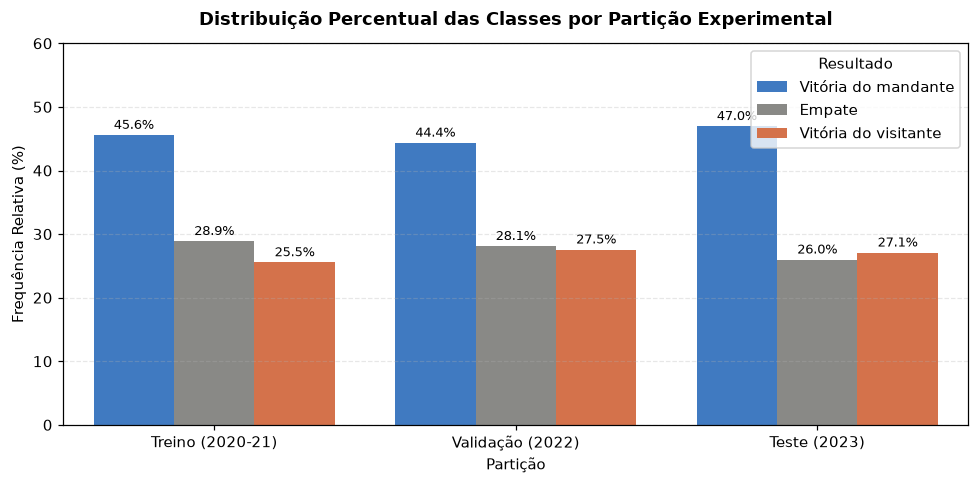

In [3]:
# Comparação gráfica da distribuição das classes
dados_barras = []
for nome, y in [("Treino (2020-21)", particoes.y_train), 
                ("Validação (2022)", particoes.y_val), 
                ("Teste (2023)", particoes.y_test)]:
    vc = y.value_counts(normalize=True).sort_index()
    for classe_id, prop in vc.items():
        dados_barras.append({
            "Partição": nome,
            "Resultado": ROTULO_RESULTADO[CLASSES[classe_id]],
            "Proporção (%)": prop * 100
        })

df_barras = pd.DataFrame(dados_barras)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=df_barras, x="Partição", y="Proporção (%)", hue="Resultado", palette=["#2a78d6", "#8a8985", "#eb6834"], ax=ax)
ax.set_title("Distribuição Percentual das Classes por Partição Experimental", fontsize=12, fontweight="bold", pad=12)
ax.set_ylabel("Frequência Relativa (%)")
ax.set_ylim(0, 60)
ax.grid(axis="y", linestyle="--", alpha=0.3)
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h),
                    ha="center", va="bottom", fontsize=8.5, xytext=(0, 2), textcoords="offset points")
plt.tight_layout()
plt.show()


## 3. Espaço de Atributos e Engenharia Pré-Jogo

Nenhum dado que ocorre durante ou após a partida é admitido como entrada.
As variáveis englobam:
1. **Históricas Móveis:** Médias e contagens dos últimos 5 jogos de mandante e visitante (pontos, saldo, gols, cartões).
2. **Diferenciais de Confronto:** Diferença direta entre o rendimento recente de mandante e visitante.
3. **Mando de Campo:** Aproveitamento específico do mandante em casa e do visitante fora.
4. **Contexto/Calendário e Equipes:** Mês, hora, dia da semana e nomes dos clubes.


In [4]:
print(f"Total de variáveis preditivas: {len(particoes.features_numericas) + len(particoes.features_categoricas)}")
print(f"- Numéricas ({len(particoes.features_numericas)}):", particoes.features_numericas[:8], "...")
print(f"- Categóricas ({len(particoes.features_categoricas)}):", particoes.features_categoricas)

# Amostra das primeiras 5 linhas de entrada (X_train)
particoes.X_train.head(5)


Total de variáveis preditivas: 34
- Numéricas (31): ['pontos_media_ultimos_5_mandante', 'vitorias_ultimos_5_mandante', 'empates_ultimos_5_mandante', 'derrotas_ultimos_5_mandante', 'gols_marcados_media_ultimos_5_mandante', 'gols_sofridos_media_ultimos_5_mandante', 'saldo_gols_media_ultimos_5_mandante', 'amarelos_media_ultimos_5_mandante'] ...
- Categóricas (3): ['home_team', 'away_team', 'dia_semana']


,pontos_media_ultimos_5_mandante,vitorias_ultimos_5_mandante,empates_ultimos_5_mandante,derrotas_ultimos_5_mandante,gols_marcados_media_ultimos_5_mandante,gols_sofridos_media_ultimos_5_mandante,saldo_gols_media_ultimos_5_mandante,amarelos_media_ultimos_5_mandante,expulsoes_media_ultimos_5_mandante,aproveitamento_ultimos_5_mandante,...,dif_pontos_media_ultimos_5,dif_saldo_gols_media_ultimos_5,dif_gols_marcados_media_ultimos_5,dif_gols_sofridos_media_ultimos_5,dif_aproveitamento_ultimos_5,dif_aproveitamento_mando,expectativa_total_gols_ultimos_5,home_team,away_team,dia_semana
0,1.0,1.0,2.0,2.0,0.8,1.0,-0.2,2.2,0.2,0.333333,...,0.0,0.0,-0.4,-0.4,0.000000,NaN,2.2,Fortaleza EC,Red Bull Bragantino,sábado
1,1.4,2.0,1.0,2.0,1.2,1.2,0.0,1.8,0.2,0.466667,...,0.4,0.6,0.6,0.0,0.133333,NaN,2.4,Santos FC Sao Paulo,CR Flamengo,domingo
2,0.6,1.0,0.0,4.0,0.6,1.4,-0.8,2.8,0.4,0.200000,...,-0.2,-0.2,-0.2,0.0,-0.066667,NaN,2.0,Coritiba FBC,SC do Recife,domingo
3,1.4,2.0,1.0,2.0,1.0,1.2,-0.2,2.6,0.0,0.466667,...,-0.2,-1.0,-0.4,0.6,-0.066667,0.0,1.6,Ceará SC,Fortaleza EC,quarta-feira
4,2.0,3.0,1.0,1.0,1.4,1.0,0.4,3.4,0.0,0.666667,...,1.2,1.2,0.6,-0.6,0.400000,NaN,3.0,Fluminense FC,Atlético Goianiense,quarta-feira


## 4. Validação Cruzada Temporal (Walk-Forward)

A validação em janela expansiva (*Expanding Window*) simula a passagem do tempo no campeonato:
* **Fold 1:** Treina em 2020 $\rightarrow$ Valida em 2021
* **Fold 2:** Treina em 2020 + 2021 $\rightarrow$ Valida em 2022


In [5]:
for i, (train_idx, val_idx) in enumerate(obter_folds_walk_forward(particoes.df_train_val), 1):
    temp_train = particoes.df_train_val.iloc[train_idx]["temporada"].unique()
    temp_val = particoes.df_train_val.iloc[val_idx]["temporada"].unique()
    print(f"Fold {i}: Treino {temp_train} ({len(train_idx)} jogos) -> Validação {temp_val} ({len(val_idx)} jogos)")


Fold 1: Treino [2020] (327 jogos) -> Validação [2021] (362 jogos)
Fold 2: Treino [2020 2021] (689 jogos) -> Validação [2022] (363 jogos)


## 5. Treinamento e Comparação de Modelos na Validação (Temporada 2022)

Avaliamos 4 abordagens distintas:
1. **Linha de Base Ingênua (Dummy):** Prediz sempre a vitória do mandante (`home_win`), classe majoritária.
2. **Regressão Logística Multinomial:** Modelo linear regularizado L2 com padronização e codificação One-Hot.
3. **Random Forest:** Ensemble de 200 árvores de decisão com limitação de profundidade.
4. **HistGradientBoosting:** Modelo baseado em árvores com gradient boosting adaptado para dados tabulares.


In [6]:
modelos = construir_modelos(particoes.features_numericas, particoes.features_categoricas)
resultados_val = []

for nome, pipe in modelos.items():
    pipe.fit(particoes.X_train, particoes.y_train)
    res = avaliar_modelo(pipe, particoes.X_val, particoes.y_val, nome, "Validação (2022)")
    resultados_val.append({
        "Modelo": res.nome_modelo,
        "Acurácia Global": f"{res.acuracia*100:.2f}%",
        "Acurácia Balanceada": f"{res.acuracia_balanceada*100:.2f}%",
        "Macro F1": f"{res.f1_macro:.3f}",
        "F1 Mandante": f"{res.f1_home_win:.3f}",
        "F1 Empate": f"{res.f1_draw:.3f}",
        "F1 Visitante": f"{res.f1_away_win:.3f}",
        "Log-Loss": f"{res.log_loss_val:.3f}" if not np.isnan(res.log_loss_val) else "—",
        "Brier Score": f"{res.brier_score:.3f}" if not np.isnan(res.brier_score) else "—",
    })

pd.DataFrame(resultados_val)


,Modelo,Acurácia Global,Acurácia Balanceada,Macro F1,F1 Mandante,F1 Empate,F1 Visitante,Log-Loss,Brier Score
0,Baseline (Majoritária),44.35%,33.33%,0.205,0.615,0.000,0.000,20.057,1.113
1,Regressão Logística,41.60%,37.42%,0.370,0.539,0.271,0.299,1.122,0.674
2,Random Forest,43.53%,33.92%,0.257,0.613,0.122,0.036,1.059,0.639
3,HistGradientBoosting,37.19%,33.22%,0.326,0.495,0.251,0.233,1.172,0.700


### 5.1 Gráfico Comparativo de Desempenho na Validação

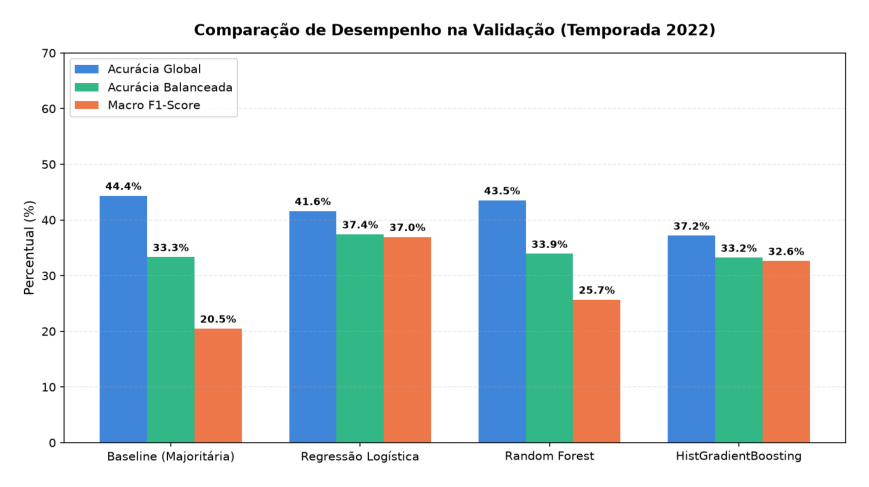

In [7]:
from PIL import Image
img_comp = Image.open("../reports/figures/14_comparacao_modelos_validacao.png")
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.imshow(img_comp)
ax.axis('off')
plt.show()


## 6. Retreino Expandido e Avaliação Final no Teste (Temporada 2023)

O modelo com maior Macro F1 na validação é retreinado com **todo o histórico disponível** até o final de 2022 (temporadas 2020 a 2022) e avaliado de forma cega nas partidas da temporada de 2023.

In [8]:
# Seleciona pelo Macro F1 da validação (a baseline não concorre) e retreina em 2020-2022
validacao = {r["Modelo"]: float(r["Macro F1"]) for r in resultados_val if "Baseline" not in r["Modelo"]}
nome_melhor = max(validacao, key=validacao.get)
print("Modelo selecionado pela validação:", nome_melhor)
melhor_modelo = modelos[nome_melhor]
melhor_modelo.fit(particoes.X_train_val, particoes.y_train_val)

dummy = modelos["Baseline (Majoritária)"]
dummy.fit(particoes.X_train_val, particoes.y_train_val)

res_teste = avaliar_modelo(melhor_modelo, particoes.X_test, particoes.y_test, nome_melhor, "Teste (2023)")
res_dummy_teste = avaliar_modelo(dummy, particoes.X_test, particoes.y_test, "Baseline", "Teste (2023)")

tabela_final = pd.DataFrame([
    {"Métrica": "Acurácia Global", "Baseline Majoritária": f"{res_dummy_teste.acuracia*100:.2f}%", nome_melhor: f"{res_teste.acuracia*100:.2f}%",
     "Diferença": f"{(res_teste.acuracia - res_dummy_teste.acuracia)*100:+.2f} p.p."},
    {"Métrica": "Acurácia Balanceada", "Baseline Majoritária": f"{res_dummy_teste.acuracia_balanceada*100:.2f}%", nome_melhor: f"{res_teste.acuracia_balanceada*100:.2f}%",
     "Diferença": f"{(res_teste.acuracia_balanceada - res_dummy_teste.acuracia_balanceada)*100:+.2f} p.p."},
    {"Métrica": "Precisão macro", "Baseline Majoritária": f"{res_dummy_teste.precisao_macro:.3f}", nome_melhor: f"{res_teste.precisao_macro:.3f}",
     "Diferença": f"{res_teste.precisao_macro - res_dummy_teste.precisao_macro:+.3f}"},
    {"Métrica": "Recall macro", "Baseline Majoritária": f"{res_dummy_teste.recall_macro:.3f}", nome_melhor: f"{res_teste.recall_macro:.3f}",
     "Diferença": f"{res_teste.recall_macro - res_dummy_teste.recall_macro:+.3f}"},
    {"Métrica": "Macro F1-Score", "Baseline Majoritária": f"{res_dummy_teste.f1_macro:.3f}", nome_melhor: f"{res_teste.f1_macro:.3f}",
     "Diferença": f"{res_teste.f1_macro - res_dummy_teste.f1_macro:+.3f}"},
    {"Métrica": "F1 Vitória Mandante", "Baseline Majoritária": f"{res_dummy_teste.f1_home_win:.3f}", nome_melhor: f"{res_teste.f1_home_win:.3f}",
     "Diferença": f"{res_teste.f1_home_win - res_dummy_teste.f1_home_win:+.3f}"},
    {"Métrica": "F1 Empate", "Baseline Majoritária": f"{res_dummy_teste.f1_draw:.3f}", nome_melhor: f"{res_teste.f1_draw:.3f}",
     "Diferença": f"{res_teste.f1_draw - res_dummy_teste.f1_draw:+.3f}"},
    {"Métrica": "F1 Vitória Visitante", "Baseline Majoritária": f"{res_dummy_teste.f1_away_win:.3f}", nome_melhor: f"{res_teste.f1_away_win:.3f}",
     "Diferença": f"{res_teste.f1_away_win - res_dummy_teste.f1_away_win:+.3f}"},
    {"Métrica": "Log-Loss (probabilidades do modelo)", "Baseline Majoritária": "n/a (probabilidades 0 ou 1)", nome_melhor: f"{res_teste.log_loss_val:.3f}", "Diferença": "—"},
])
display(tabela_final)


Modelo selecionado pela validação: Regressão Logística


,Métrica,Baseline Majoritária,Regressão Logística,Diferença
0,Acurácia Global,46.96%,44.48%,-2.49 p.p.
1,Acurácia Balanceada,33.33%,37.26%,+3.93 p.p.
2,Precisão macro,0.157,0.388,+0.231
3,Recall macro,0.333,0.373,+0.039
4,Macro F1-Score,0.213,0.360,+0.147
5,F1 Vitória Mandante,0.639,0.594,-0.045
6,F1 Empate,0.000,0.221,+0.221
7,F1 Vitória Visitante,0.000,0.264,+0.264
8,Log-Loss (probabilidades do modelo),n/a (probabilidades 0 ou 1),1.089,—


### 6.1 Matriz de Confusão no Teste (Temporada 2023)

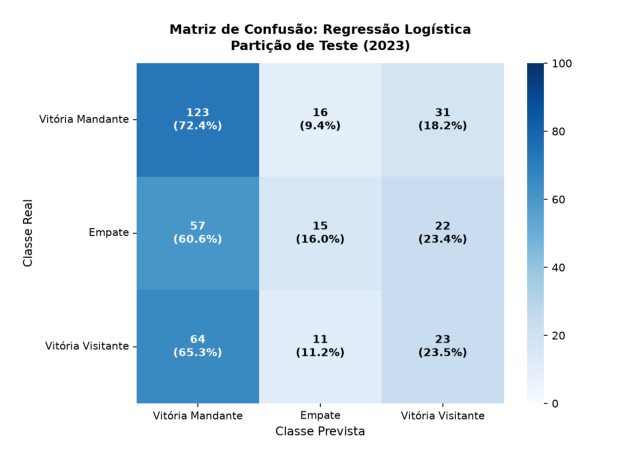

In [9]:
img_cm = Image.open("../reports/figures/15_matriz_confusao_teste.png")
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(img_cm)
ax.axis('off')
plt.show()


## 7. Relevância das Features e Interpretabilidade

Importância por permutação (aumento do log-loss no teste ao embaralhar cada atributo). É uma associação do modelo, não uma relação causal:

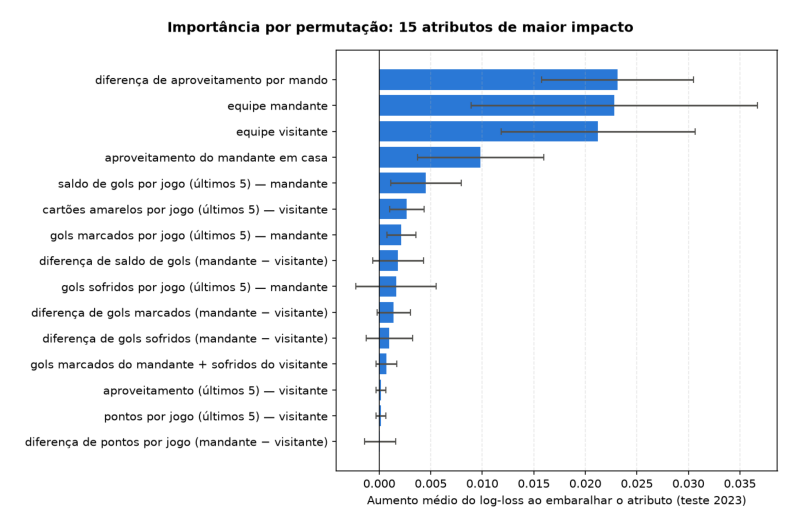

In [10]:
img_feat = Image.open("../reports/figures/16_importancia_permutacao.png")
fig, ax = plt.subplots(figsize=(9.5, 6))
ax.imshow(img_feat)
ax.axis('off')
plt.show()


In [11]:
from IPython.display import Markdown, display
fmt = lambda v: f"{v:.2%}".replace(".", ",")
display(Markdown(f'''## 8. Conclusões e considerações metodológicas

1. **Protocolo temporal:** treino em 2020-2021, validação em 2022 e teste em 2023. Históricos anteriores ao jogo e transformações ajustadas no treino evitam incorporar a própria partida nas entradas. O teste pode usar partidas anteriores já encerradas em 2023.
2. **Desempenho:** {nome_melhor} obteve Macro F1 de {res_teste.f1_macro:.3f} e acurácia balanceada de {fmt(res_teste.acuracia_balanceada)}, contra {res_dummy_teste.f1_macro:.3f} e {fmt(res_dummy_teste.acuracia_balanceada)} da referência majoritária. A acurácia global foi {fmt(res_teste.acuracia)} (referência: {fmt(res_dummy_teste.acuracia)}). Empates reconhecidos: {res_teste.matriz_confusao[1][1]} de {res_teste.matriz_confusao[1].sum()}; vitórias de visitantes: {res_teste.matriz_confusao[2][2]} de {res_teste.matriz_confusao[2].sum()}.
3. **Interpretação:** a importância por permutação e os coeficientes são associações do modelo; não indicam causalidade.
4. **Probabilidades:** Log-Loss do modelo {res_teste.log_loss_val:.3f}. O relatório final compara também uma referência de frequências históricas; não há evidência de superioridade geral.

Consulte `reports/relatorio_tecnico.pdf` e o notebook `03_demonstracao_funcionamento.ipynb` para as evidências consolidadas.'''))


## 8. Conclusões e considerações metodológicas

1. **Protocolo temporal:** treino em 2020-2021, validação em 2022 e teste em 2023. Históricos anteriores ao jogo e transformações ajustadas no treino evitam incorporar a própria partida nas entradas. O teste pode usar partidas anteriores já encerradas em 2023.
2. **Desempenho:** Regressão Logística obteve Macro F1 de 0.360 e acurácia balanceada de 37,26%, contra 0.213 e 33,33% da referência majoritária. A acurácia global foi 44,48% (referência: 46,96%). Empates reconhecidos: 15 de 94; vitórias de visitantes: 23 de 98.
3. **Interpretação:** a importância por permutação e os coeficientes são associações do modelo; não indicam causalidade.
4. **Probabilidades:** Log-Loss do modelo 1.089. O relatório final compara também uma referência de frequências históricas; não há evidência de superioridade geral.

Consulte `reports/relatorio_tecnico.pdf` e o notebook `03_demonstracao_funcionamento.ipynb` para as evidências consolidadas.